Original Weather Data:
     Sky  Temp Humidity    Wind Class
0  Sunny  Warm   Normal  Strong   Yes
1  Sunny  Warm     High  Strong   Yes
2  Rainy  Cold     High  Strong    No
3  Sunny  Warm     High    Weak   Yes


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


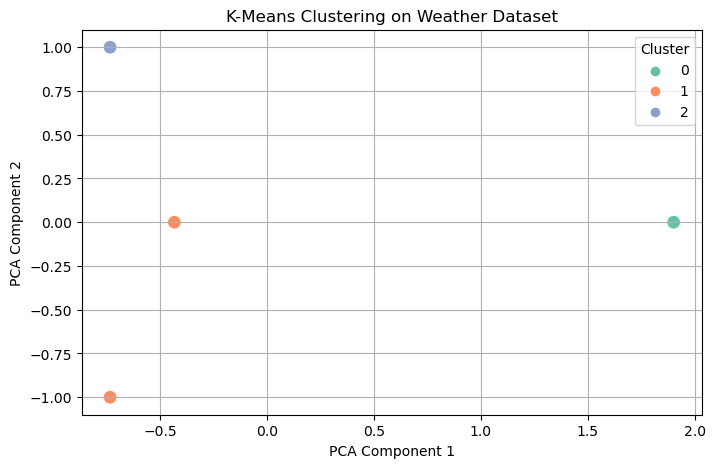


Clustered Weather Data:
   Cluster    Sky  Temp Humidity    Wind Class
0        2  Sunny  Warm   Normal  Strong   Yes
1        1  Sunny  Warm     High  Strong   Yes
2        0  Rainy  Cold     High  Strong    No
3        1  Sunny  Warm     High    Weak   Yes


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\Admini\Pictures\ML - 2 Data_Set\weather.xls")
print("Original Weather Data:")
print(df.head())
encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(df).toarray()
# Apply K-Means clustering (choose k=3 or based on use-case)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_encoded)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title("K-Means Clustering on Weather Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()
print("\nClustered Weather Data:")
print(df[['Cluster'] + df.columns[:-3].tolist()]) # Reorder for clarity